In [1]:
from scipy import constants as const
import numpy as np
from matplotlib import pyplot as plt

# Dynamics of fields in a Fabry-Perot cavity

The dynamics are described by the difference equation (Rakhmanov Eq. 1.50):

$E(t) = t_a E_\mathrm{in}(t) + r_a r_b e^{-2 i k d(t)} E(t-2T)$

where:
* $t_a$ is the transmissivity of the input mirror;
* $E_\mathrm{in}(t)$ is input laser field;
* $r_a$ and $r_b$ are the reflectivities of the mirrors (a - input, b - output);
* $k = \omega / c = 2\pi / \lambda$ is the wavenumber;
* $d(t) = L + x_b(t-T) - x_a(t) = L + \xi$ is physical length of the cavity (Rakhmanov Eq. 1.33);
* $T = \frac{L}{c}$ is half of the round-trip time;
* $L$ is half of the round-trip;
* $E(t-2T)$ is the field inside the cavity at the time before one round-trip.

In [2]:
t_a = 0.1
r_a = 0.9
r_b = 0.9
L = 3000  # m
T = L/const.c  # s
E_in_avg = 1  #
lambd = 1064e-9  # m
k = 2*np.pi / lambd

Loss = 1. - np.power(t_a,2) - np.power(r_a,2)
if  Loss < 0.:
    print("Attenti ai valori")
else:
    print("Loss: {0}".format(Loss))

Loss: 0.17999999999999994


In [3]:
def N_eff(r_a, r_b):
    '''
    Effective number of photon round trips in a FabryPerot cavity (Rakhmanov Eq. 1.57)
    '''
    return 1./np.abs(np.log(r_a*r_b))

## Finesse and cavity decay time

Coefficient of finesse:

$F = \frac{4 r_a r_b}{(1 - r_a r_b)^2}$

$\tau_s = \frac{FL}{c\pi}$

Finesse ($\mathcal{F}$) of the cavity:

$\mathcal{F} = \frac{\pi}{2} \sqrt{F}$

Approximately: $\mathcal{F} = \pi N_\mathrm{eff}$

In [4]:
def F():
    '''
    Coefficient of finesse
    '''
    return 4.*r_a*r_b / np.power(1.-r_a*r_b, 2)

def tau_s():
    '''
    Formula equivalent to Eq. 2.17 (Rakhmanov)

    return 2. * T * N_eff(r_a, r_b)
    '''
    return F() * L / (np.pi * const.c)

def Finesse(F):
    '''
    Finesse
    '''
    return np.sqrt(F) * np.pi / 2.

In [5]:
print("Coefficient of finesse: {0:.2f}".format(F()))

print("Tau_s: {0}".format(tau_s()))

print("Finesse: {0}".format(Finesse(F())))

Coefficient of finesse: 89.75
Tau_s: 0.0002858831030486214
Finesse: 14.881228359109551


## Critical velocity

$v_\mathrm{cr} = \frac{\lambda}{2\tau\mathcal{F}}$

where $\tau$ is the storage time:

$\tau = 2 T N_\mathrm{eff}$

In [6]:
def tau():
    return 2. * T * N_eff(r_a, r_b)

In [7]:
def v_cr():
    return lambd / (2. * Finesse(F()) * tau())  # In [m/s]!

In [8]:
v_cr()

0.0003764004958010008

## Airy function

In [9]:
def Airy(F, phi):
    return 1. / (1. + F * np.sin(phi)**2)

## Cavity gain

$E = g A$

where $g$ ia the amplitude gain of the Fabry-Perot cavity:

$g = \frac{t_a}{1-r_a r_b}$

Power gain:

$P = g^2 P_\mathrm{in}$

In [10]:
def gain():
    return t_a / (1. - r_a*r_b)

## Cavity parameters summary

In [11]:
N_eff(r_a, r_b)

4.745610790514953

In [12]:
T

1.0006922855944561e-05

In [13]:
gain()

0.5263157894736844

## Some cases of $d(t)$

* $d(t) = const.$
* $d(t) = A\sin(2\pi f t)$
* $d(t) = arb(t)$ -- arbitrary function of time

In [14]:
v = 1.e-6/0.1  # m/s

v = 3*v_cr()
#v = 0.00037640

def d(t):
    # Constant
    #return 2

    # Linear    
    #c = 1.
    return v*t + L

    # Sinusoidal
    A = 1.e-7
    f = 200.e6  # Hz
    #return A*np.sin(2.*np.pi*f*t)

In [15]:
def E_in(t):
    return 1.
    #return A*np.sin(2.*np.pi*f*t)

In [16]:
def x_a(t):
    return 0.0

In [17]:
def S_n(t, n, T):
    '''
    2 S_n is the optical path length for a photon which completed n round trips in the cavity.
    
    t - time
    n - "order" of S function (number of round-trips)
    T - half of the cavity round-trip time
    '''
    S = 0
    for p in np.arange(1, n+1, 1):
        S = S + d(t - 2.*T*p)
    return S

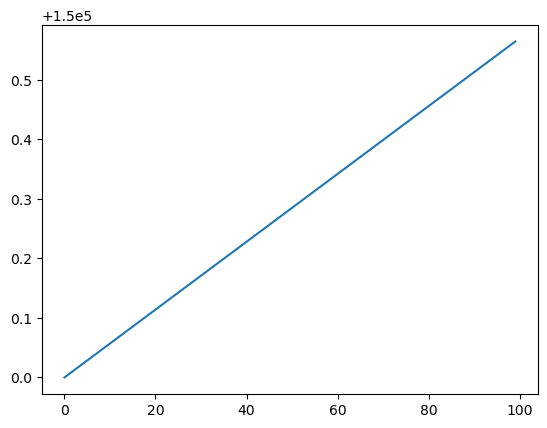

In [18]:
tdata = np.linspace(0,10,100)

res = np.zeros(100)

for idx, t in enumerate(tdata):
    res[idx] = S_n(t, 50, T)
    #print(dat)
#print(y)

plt.plot(res)

## Implementation of Eq. 1.51

In [19]:
N = 100  # Seems reasonable to sum up to 5 to 10 N_eff.
n = np.arange(0, N+1, 1)
rarbn = np.power(r_a*r_b, n) 

def E(t, N=0, recursion_level=0):
    #if t < 0.:
    #    return 0.

    if recursion_level > 100:  # TODO: Verify the accuracy!
        return 0.
        
    global t_a, r_a, r_b, T
    
    if N == 0:
        N = int(N_eff(r_a, r_b) * 5)

    '''
    if False:
        print("T_a: {0}".format(t_a))
        print("(r_a*r_b)^2: {0}".format(np.power(r_a*r_b, N)))
        print(k*S_n(t, N, T))
        #print(E(t-2.*N*T, N))
        print("--------")
    '''
    
    k2j = -2.j*k
    
    Sum = 0
    Sn = 0.
    for idx, p in enumerate(np.arange(1, N+1, 1)):
        Sum = Sum + rarbn[idx] * np.exp(k2j*Sn) * E_in(t-2.*p*T)
        Sn = Sn + d(t - 2.*T*p)

    try:
        E_last = E(t - 2.*N*T, N, recursion_level=recursion_level+1)
    except RecursionError:
        print("Recursion lvl: {0}".format(recursion_level))
        E_last = 0.
        
    res = t_a * Sum + rarbn[int(N)] * np.exp(k2j*Sn) * E_last
    return res

In [20]:
E(0.01)

(0.034909736406957124+0.030432120309273832j)

## Definition of useful arrays

In [21]:
number_of_points = 1000

tdata = np.linspace(0., .1, number_of_points)

Adata = np.zeros(number_of_points, dtype=np.complex_)
res = np.zeros(number_of_points, dtype=np.complex_)
ein = np.zeros(number_of_points, dtype=np.complex_)
eref = np.zeros(number_of_points, dtype=np.complex_) #for the values of the reflected field
dyn = np.zeros(number_of_points, dtype=np.complex_) #for the values of the field inside the cavity in case of lenght scan transient
res_dyn = np.zeros(number_of_points, dtype=np.complex_) #for the values of the cavity field obtained numerically


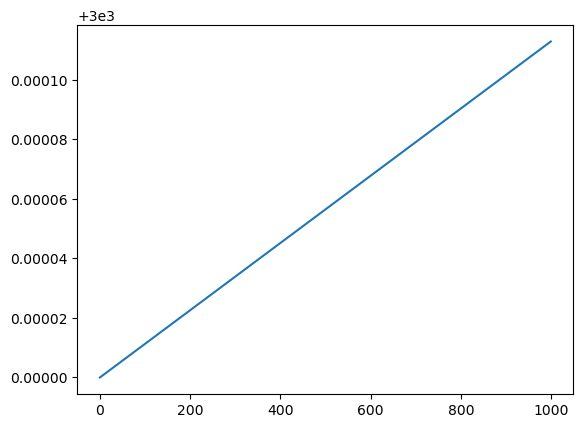

In [22]:
plt.plot(d(tdata))

## Automation of the comparison between numerical solution and Airy function with selectable velocity.

The function `simulation_check` aims to automatize the process of compare the numerical simulation with the analitycal solution (Airy function), giving the possibility to choose the velocity of $d(t)$ and compute the right time window for visualizing 2 free spectral range. The correct time window is calculated through the function `time_window`.

In [23]:
def d2(t,v, type):
    if type=="const":
        return 2
    if type=="linear":
        return v*t + L
    if type=="sin":
        A = 1.e-7
        f = 200.e6  # Hz
        return A*np.sin(2.*np.pi*f*t)

In [24]:
def time_window(v, number_of_points):
    t_stop = lambd/v
    return np.linspace(0.,t_stop,number_of_points)

In [25]:
Adata = Airy(F(), (time_window(v, number_of_points)*k-.2867895)*v)

In [26]:
N = 100  # Seems reasonable to sum up to 5 to 10 N_eff.
n = np.arange(0, N+1, 1)
rarbn = np.power(r_a*r_b, n) 

def E(t, v, type_d, N=0, recursion_level=0):
    #if t < 0.:
    #    return 0.

    if recursion_level > 100:  # TODO: Verify the accuracy!
        return 0.
        
    global t_a, r_a, r_b, T
    
    if N == 0:
        N = int(N_eff(r_a, r_b) * 5)
        
    '''
    if False:
        print("T_a: {0}".format(t_a))
        print("(r_a*r_b)^2: {0}".format(np.power(r_a*r_b, N)))
        print(k*S_n(t, N, T))
        #print(E(t-2.*N*T, N))
        print("--------")
    '''
    
    k2j = -2.j*k
    
    Sum = 0
    Sn = 0.
    for idx, p in enumerate(np.arange(1, N+1, 1)):
        Sum = Sum + rarbn[idx] * np.exp(k2j*Sn) * E_in(t-2.*p*T)
        Sn = Sn + d2(t - 2.*T*p, v, type_d )

    try:
        E_last = E(t - 2.*N*T, v, type_d, N, recursion_level=recursion_level+1)
    except RecursionError:
        print("Recursion lvl: {0}".format(recursion_level))
        E_last = 0.
        
    res = t_a * Sum + rarbn[int(N)] * np.exp(k2j*Sn) * E_last
    return res

In [27]:
def simulation_check(v, number_of_points, type_d):


    tdata=time_window(v, number_of_points)

    for idx, t in enumerate(tdata):
        ein[idx] = E_in(t)
        res[idx] = E(t, v, type_d, N=25)
    
    Adata = Airy(F(), (tdata*k+0.2867895)*v)

    plt.figure()
    plt.plot(tdata, abs(res)**2/gain(), label="Numerical magn")
    plt.plot(tdata, Adata*gain(), label="Airy")
    plt.xlabel("Time [s]")
    plt.legend()

    plt.figure()
    plt.plot(tdata, np.unwrap(np.angle(res, deg=True)*2)/2, label="Numerical phase")
    #plt.plot(tdata, np.angle(res, deg=True), label="Numerical phase")
    plt.xlabel("Time [s]")
    plt.legend()

    return plt.show()

If you want to keep your original phase with pi-periodicity, you should first double the phase, unwrap it, then divide it by two.

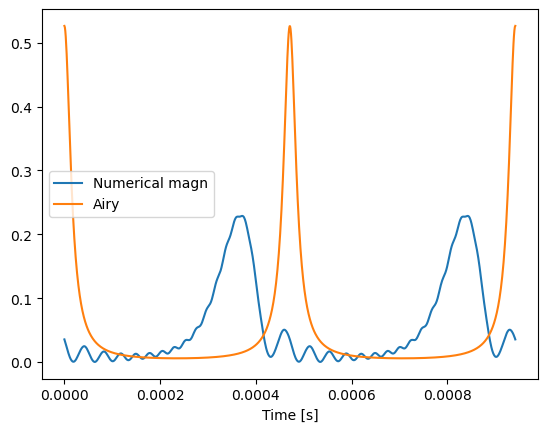

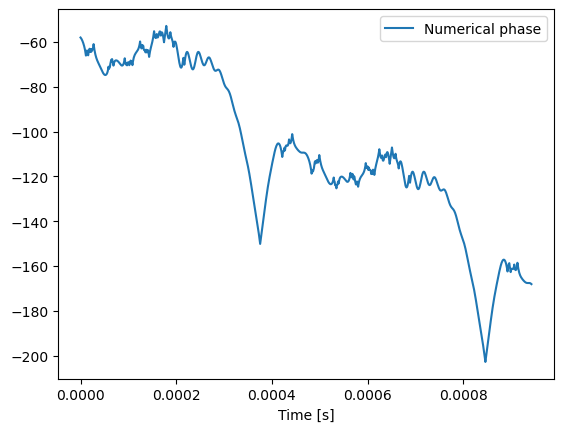

In [28]:
simulation_check(v, 1000, "linear" )

# TODO:
    1. Delay factor (0.013 in Adata)
    2. Reproduce FigureFigure2.5 (Rakhmanov)

## Delay factor
The delay factor is 0.2867895 but, in order to have a better match between Airy data and numerical values, it is possibile to compute it taking the instants in which we have the maximum value from Airy data and numerical solution and then effectuate the difference. Moreover in the function `simulation_check` we add the factor 0.2867895 to $k*t$ instead of just $t$. Here the delay factor that will be calculated has to be added to $t$ to have a perfect match.

In [29]:
np.max(abs(res)**2/gain())

0.22876040674311826

In [30]:
np.max(Adata*gain())

0.5263108355480713

In [31]:
tdata=time_window(v, number_of_points)
t_E=0
t_A=0
for idx, t in enumerate(tdata):
    ein[idx] = E_in(t)
    res[idx] = E(t, v, "linear", N=25)
    Adata[idx] = Airy(F(), (t*k-.2867895)*v)
    if abs(res[idx])**2/gain() == 0.5249204171102564:
        t_E=t
    if Adata[idx]*gain() == 0.5263157890851667:
        t_A=t

In [32]:
print(t_E)

0


In [33]:
print(t_A)

0


In [34]:
delay=t_A-t_E
print(delay)

0


In [35]:
def simulation_check(v, number_of_points, type_d):


    tdata=time_window(v, number_of_points)

    for idx, t in enumerate(tdata):
        ein[idx] = E_in(t)
        res[idx] = E(t, v, type_d, N=25)
    
    Adata = Airy(F(), (tdata+delay)*k*v)

    plt.figure()
    plt.plot(tdata, abs(res)**2/gain(), label="Numerical magn")
    plt.plot(tdata, Adata*gain(), label="Airy")
    plt.xlabel("Time [s]")
    plt.legend()

    plt.figure()
    plt.plot(tdata, np.unwrap(np.angle(res, deg=True)*2)/2, label="Numerical phase")
    #plt.plot(tdata, np.angle(res, deg=True), label="Numerical phase")
    plt.xlabel("Time [s]")
    plt.legend()

    return plt.show()

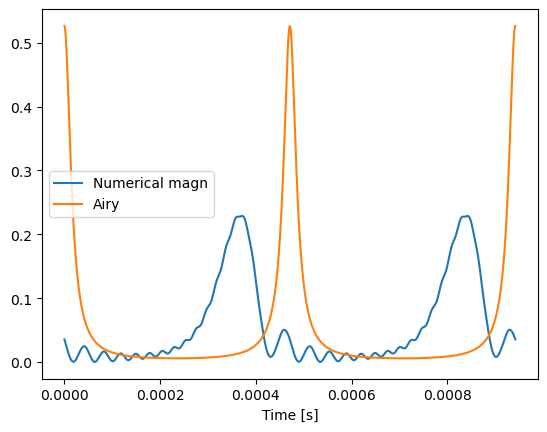

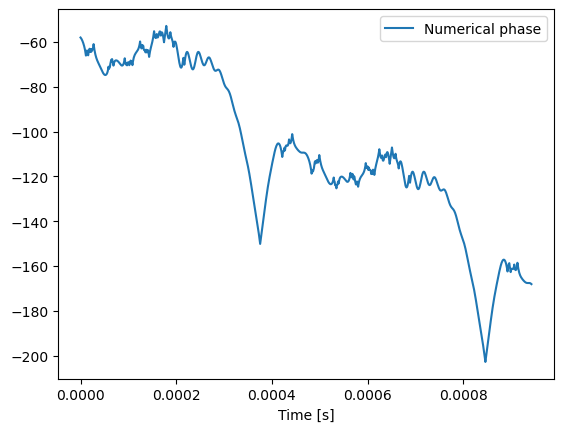

In [36]:
simulation_check(v, 1000, "linear" )

## Implementation of Eq 2.69

$\LARGE E(t) \approx D_0 e^{-\frac{t}{\tau} - i\frac{kv}{2T} t^2} + \frac{t_a A}{1-r_a r_b e^{-2ikvt}}$

where:

$\LARGE D_0 = t_a A \sqrt{\frac{i \pi}{2kvT}} e^{\frac{iT}{2kv\tau^2}}$

$\tau$ is the storage time

$k$ is the wave number

$v$ is the mirror velocity

$T$ is half of the round-trip time

In [37]:
def D_0(Ein, V):
    return t_a*Ein*np.sqrt(1.j*np.pi/(2.*k*V*T))*np.exp(1.j*T/(2.*k*V*np.power(tau(),2)))

In [38]:
def E_cr(t, Ein, V):
    doppler = D_0(Ein, V)*np.exp(-t/tau() - 1.j*k*V*np.power(t,2)/(2.*T))
    adiab = t_a*Ein/(1.-r_a*r_b*np.exp(-2.j*k*V*t))
    return doppler, adiab

## Check if the numerical simulation is computed correctly and it reproduces the cavity ringing.

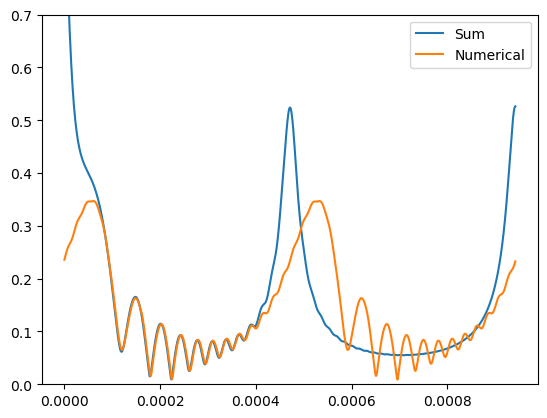

In [49]:
td = tdata
ad, do = E_cr(td, E_in_avg, v)
#plt.plot(td, np.abs(ad), label="Adiabatic")
#plt.plot(td, np.abs(do), label="Doppler")
plt.plot(td, np.abs(ad+do), label="Sum")
roll_factor = 171
res_rolled = np.roll(abs(res), roll_factor)
plt.plot(tdata, res_rolled, label="Numerical")
plt.ylim([0., 0.7])
plt.legend()

(-0.05, 0.05)

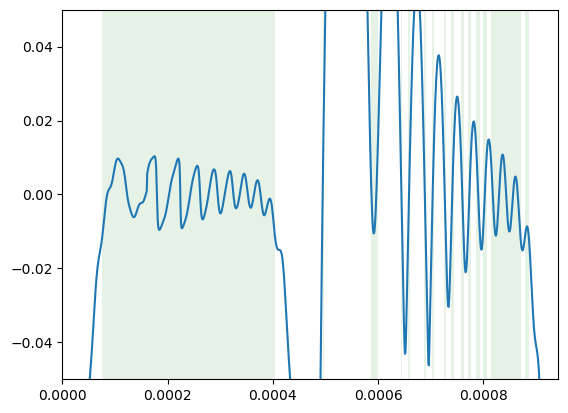

In [54]:
epsilon = 0.012

l = len(tdata)
diffr = np.zeros(l)
good_times_start = []
good_times_stops = []

last_i_start = 0
last_i_stops = 0
for i in range(l):
    diffr[i] = res_rolled[i] - np.abs(ad+do)[i]
    if abs(diffr[i]) < epsilon:
        if last_i_start + 1 != i:
            good_times_start.append(tdata[i])
            #print(tdata[i])
            
        last_i_start = i

    if abs(diffr[i]) > epsilon:
        if last_i_stops + 1 != i:
            good_times_stops.append(tdata[i])
            #print(tdata[i])
            
        last_i_stops = i

for tms in range(len(good_times_start)):
    plt.axvspan(good_times_start[tms], good_times_stops[tms+1], facecolor='green', alpha=0.1)

plt.plot(tdata, diffr)
plt.xlim([0., td[-1]])
plt.ylim([-.05, .05])

Good approximation starts after: 7.545615743135859e-05
0.13261903596201172
1.2587166561780267


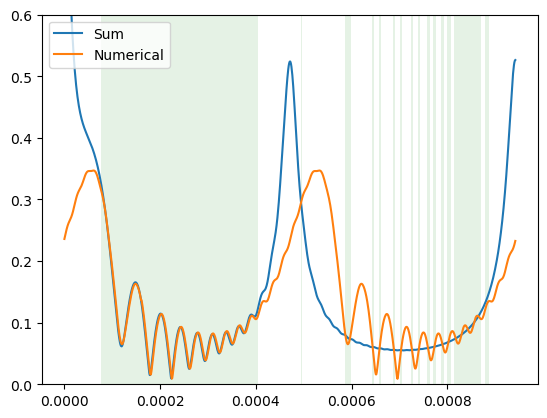

In [55]:
plt.plot(td, np.abs(ad+do), label="Sum")
plt.plot(tdata, res_rolled, label="Numerical")
plt.ylim([0., 0.6])
for tms in range(len(good_times_start)):
    plt.axvspan(good_times_start[tms], good_times_stops[tms+1], facecolor='green', alpha=0.1)
plt.legend()

print("Good approximation starts after: " + str(good_times_start[0]))
print(T/good_times_start[0])      # ~0.07 T
print(tau()/good_times_start[0])  # ~0.63 tau

In [42]:

E_cr(time_window(v_cr()/10, 1000), ein, v_cr()/10)

(array([-2.63175253e+000-3.68687401e-001j,
        -1.95606137e+000-2.56315016e-001j,
        -1.45665823e+000-1.51477493e-001j,
        -1.08529256e+000-6.42768229e-002j,
        -8.07084494e-001+2.49328627e-003j,
        -5.97080691e-001+4.97434448e-002j,
        -4.37523142e-001+8.00378910e-002j,
        -3.15778222e-001+9.64830987e-002j,
        -2.22813280e-001+1.02164039e-001j,
        -1.52099802e-001+9.98865878e-002j,
        -9.88363729e-002+9.20820786e-002j,
        -5.94056489e-002+8.07913178e-002j,
        -3.10001516e-002+6.76828400e-002j,
        -1.13689767e-002+5.40824482e-002j,
         1.34914550e-003+4.10039020e-002j,
         8.73131188e-003+2.91776831e-002j,
         1.21325740e-002+1.90783404e-002j,
         1.27183566e-002+1.09523676e-002j,
         1.14778041e-002+4.84870996e-003j,
         9.22664172e-003+6.53323906e-004j,
         6.60655081e-003-1.87191885e-003j,
         4.08659475e-003-3.04701168e-003j,
         1.97066006e-003-3.23055591e-003j,
         4.

In [43]:
vel = [v_cr()/10, v_cr(), v_cr()*10]
res_scan = {}
for i, j in zip([0,1,2], vel):
    res_scan[i] = E_cr(time_window(j, 1000), ein, j)

plt.figure()
plt.plot(time_window(v_cr()/10, number_of_points), -E_cr(time_window(v_cr()/10, 1000), ein, v_cr()/10).imag, label="v/v_cr {0:.6f}".format(0))
plt.legend()
plt.figure()
plt.plot(time_window(v_cr(), number_of_points), -E_cr(time_window(v_cr(), 1000), ein, v_cr()).imag, label="v/v_cr {0:.6f}".format(1))
plt.legend()
plt.figure()
plt.plot(time_window(v_cr()*10, number_of_points), -E_cr(time_window(v_cr()*10, 1000), ein, v_cr()*10).imag, label="v/v_cr {0:.6f}".format(2))
plt.legend()

plt.show()

AttributeError: 'tuple' object has no attribute 'imag'

<Figure size 640x480 with 0 Axes>

## Figure 2.6 but with the imaginary part of the numerical solution

In [ ]:
plt.figure()
plt.plot(time_window(v_cr()/10, number_of_points), -E(time_window(v_cr()/10, 1000), v_cr()/10, "linear").imag, label="v/v_cr {0:.6f}".format(0))
plt.legend()
plt.figure()
plt.plot(time_window(v_cr(), number_of_points), -E(time_window(v_cr(), 1000), v_cr(), "linear").imag, label="v/v_cr {0:.6f}".format(1))
plt.legend()
plt.figure()
plt.plot(time_window(v_cr()*10, number_of_points), -E(time_window(v_cr()*10, 1000), v_cr()*10, "linear").imag, label="v/v_cr {0:.6f}".format(2))
plt.legend()

plt.show()

In [ ]:
def simulation_check_dyn(v, number_of_points, type_d):


    tdata=time_window(v, number_of_points)
    tdata1=time_window(v*20, number_of_points)
    
    for idx, t in enumerate(tdata1):
        dyn[idx] = E_cr(t, ein[idx], v*20)

    for idx, t in enumerate(tdata):
        res_dyn[idx] = E(t, v, type_d, N=25)
    
    
    
    plt.figure()
    plt.plot(tdata, abs(res_dyn)**2/gain(), label="Numerical magn")
    plt.plot(tdata, abs(dyn)**2/gain(), label="Lenght scan transient")
    plt.xlabel("Time [s]")
    plt.legend()

    plt.figure()
    plt.plot(tdata, np.unwrap(np.angle(res_dyn, deg=True)*2)/2, label="Numerical phase")
    plt.plot(tdata, np.unwrap(np.angle(dyn, deg=True)*2)/2, label="Numerical phase")
    plt.xlabel("Time [s]")
    plt.legend()

    return plt.show()

In [ ]:
simulation_check_dyn(v_cr(), 1000, "linear")

In [ ]:
plt.plot(time_window(v_cr(), number_of_points), abs(res_scan[1])**2/gain(), label="v/v_cr {0:.5f}".format(j))
#plt.plot(time_window(v_cr(), number_of_points), abs((res**2)/gain()), label = "numerical solution")
plt.legend()

## Figure 2.6 $\frac{v}{v_{cr}} = 0.1$

In [ ]:
plt.plot(time_window(v_cr()/10, number_of_points),-res_scan[0].imag)

## Figure 2.6 $\frac{v}{v_{cr}} = 1$

In [ ]:
plt.plot(time_window(v_cr(), 1000), -res_scan[1].imag)

## Figure 2.6 $\frac{v}{v_{cr}} = 10$

In [ ]:
plt.plot(time_window(v_cr()*10, 1000), -res_scan[2].imag)

# Pound-Drever-Hall

In [ ]:
plt.plot(time_window(v, 1000), res.imag)

In [ ]:
gamma = np.pi/2
def V_pdh(gamma,res):
    return -(np.exp(gamma*1.j) * np.conjugate(ein) * res).imag

for i in np.linspace(0., np.pi/2, 3):
    plt.plot(time_window(v, 1000), V_pdh(i, res), label="phase: {0:.2f}".format(i))

plt.legend()

In [ ]:
def V_pdh_scan(gamma, res):
    return -(np.exp(gamma*1.j) * np.conjugate(ein) * res).imag

In [ ]:
for i in np.linspace(0., np.pi/2, 3):
    plt.plot(time_window(v_cr(), 1000), V_pdh_scan(i, res_dyn), label="phase: {0:.2f}".format(i))
    plt.plot(time_window(v_cr(), 1000), V_pdh_scan(i,res_scan[1]),'--', label="phase: {0:.2f}".format(i))
plt.legend()

## Adjusted Pound-Drever signal Eq 2.85

In [ ]:
def V_pdh_D(t, v, Ein, gamma):
    t_0=v*lambd/2
    return - Ein*np.abs(D_0(Ein, v))**2*np.exp(t-t_0/tau())*np.sin(gamma+np.angle(D_0(Ein,v))-k*v*(t-t_0)**2/2*T)

In [ ]:
def x_a(t):
    return 0.0

In [ ]:
def E_ref(t, Edt):
    return np.exp(-2.j*k*x_a(t)) * ((r_a**2 + t_a**2)*E_in(t) - t_a * Edt) / r_a #Eq 1.48

tdata = time_window(v, number_of_points)

for idx, t in enumerate(tdata):
    ein[idx] = E_in(t)
    res[idx] = E(t,v,"linear", N=25)
    eref[idx] = E_ref(t, res[idx])

R_coeff = eref/ein

In [ ]:
plt.figure()
plt.plot(tdata,np.abs(R_coeff), label="Reflected power")
plt.legend()
plt.figure()
plt.plot(tdata,np.unwrap(np.angle(R_coeff,deg=True)*2)/2, label="Reflected phase",color="orange")
plt.legend()
plt.show()

## Reflected field for scan transient with critical velocity

In [ ]:
res_scan_dyn = np.zeros(number_of_points, dtype = np.complex_)
eref_scan = np.zeros(number_of_points, dtype = np.complex_)
res_dyn = E(time_window(v_cr(), 1000), v_cr(), "linear", N=25)

for idx, t in enumerate(time_window(v_cr(), 1000)):
    res_scan_dyn[idx] = E_cr(t, ein[idx], v_cr())
    eref_scan[idx] = E_ref(t, res_dyn[idx])
R_coeff_scan = eref_scan/ein

In [ ]:
plt.figure()
plt.plot(np.abs(R_coeff_scan), label="Reflected power")
plt.legend()

plt.figure()
plt.plot(np.angle(R_coeff_scan), label="Reflected phase",color="orange")
plt.legend()

plt.show()

# TODO:
    1. Confrontare Reflected power to model in Finesse